# 05 — xG Models

**What this notebook does:** Trains Logistic Regression (interpretable baseline) and XGBoost (main model) xG models on 490k shots with 5-fold cross-validation. Evaluates using Brier score, ROC-AUC, and calibration plots. Computes SHAP feature importance.

**Key output:** `data/outputs/xg_predictions.csv` — three xG baselines per shot (Understat, LR, XGBoost).


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import numpy as np
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
from pathlib import Path
OUTPUTS_DIR = Path('../data/outputs')
PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
import pickle
from src.xg_model import (train_logistic, train_xgboost, predict_xg,
                           calibration_plot, shap_importance,
                           MODEL_FEATURES, LR_FEATURES)
from src.visualise import xg_comparison_scatter


## 5.1  Load clustered shot data

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'shots_clustered.csv')
print(f"Loaded: {df.shape}")
print(f"Goal rate: {df['goal'].mean():.3f}")
print(f"LR features  ({len(LR_FEATURES)}): {LR_FEATURES}")
print(f"XGB features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}")


Loaded: (490204, 34)
Goal rate: 0.098
LR features  (9): ['distance', 'angle', 'is_header', 'is_right_foot', 'is_left_foot', 'from_corner', 'from_set_piece', 'from_freekick', 'preceded_by_cross']
XGB features (16): ['distance', 'angle', 'is_header', 'is_right_foot', 'is_left_foot', 'from_corner', 'from_set_piece', 'from_freekick', 'preceded_by_cross', 'preceded_by_aerial', 'preceded_by_dribble', 'preceded_by_throughball', 'preceded_by_rebound', 'preceded_by_layoff', 'shot_in_box', 'minute']


## 5.2  Load pre-computed predictions (or train if missing)

In [3]:
pred_path = OUTPUTS_DIR / 'xg_predictions.csv'

if pred_path.exists():
    df_pred = pd.read_csv(pred_path)
    print(f"Loaded pre-computed predictions: {df_pred.shape}")
    # Re-train to get model objects for plots (fast since CV already done)
    print("\nRe-training models for SHAP / calibration objects...")
    lr_model,  lr_scaler, lr_metrics  = train_logistic(df)
    xgb_model, xgb_metrics            = train_xgboost(df)
else:
    print("No cached predictions found — training from scratch...")
    lr_model,  lr_scaler, lr_metrics  = train_logistic(df)
    xgb_model, xgb_metrics            = train_xgboost(df)
    df_pred = predict_xg(df, lr_model, lr_scaler, xgb_model)
    print(f"Saved xg_predictions.csv")


Loaded pre-computed predictions: (490204, 8)

Re-training models for SHAP / calibration objects...


Logistic Regression CV results:
  roc_auc_mean: 0.7753
  roc_auc_std: 0.0018
  brier_mean: 0.0772
  brier_std: 0.0002
  log_loss_mean: 0.2728
  log_loss_std: 0.0006


XGBoost CV results:
  roc_auc_mean: 0.7918
  roc_auc_std: 0.0022
  brier_mean: 0.0757
  brier_std: 0.0002
  log_loss_mean: 0.2658
  log_loss_std: 0.0009


## 5.3  Model comparison — CV metrics

In [4]:
metrics_table = pd.DataFrame({
    'Model':     ['Understat xG (baseline)', 'Logistic Regression', 'XGBoost'],
    'ROC-AUC':   [
        '—',
        f"{lr_metrics['roc_auc_mean']:.4f} ± {lr_metrics['roc_auc_std']:.4f}",
        f"{xgb_metrics['roc_auc_mean']:.4f} ± {xgb_metrics['roc_auc_std']:.4f}",
    ],
    'Brier Score': [
        f"{df_pred['xg_understat'].dropna().sub(df_pred.loc[df_pred['xg_understat'].notna(),'goal']).pow(2).mean():.4f}",
        f"{lr_metrics['brier_mean']:.4f} ± {lr_metrics['brier_std']:.4f}",
        f"{xgb_metrics['brier_mean']:.4f} ± {xgb_metrics['brier_std']:.4f}",
    ],
    'Log Loss': [
        '—',
        f"{lr_metrics['log_loss_mean']:.4f} ± {lr_metrics['log_loss_std']:.4f}",
        f"{xgb_metrics['log_loss_mean']:.4f} ± {xgb_metrics['log_loss_std']:.4f}",
    ],
})
print(metrics_table.to_string(index=False))
metrics_table


                  Model         ROC-AUC     Brier Score        Log Loss
Understat xG (baseline)               —          0.0709               —
    Logistic Regression 0.7753 ± 0.0018 0.0772 ± 0.0002 0.2728 ± 0.0006
                XGBoost 0.7918 ± 0.0022 0.0757 ± 0.0002 0.2658 ± 0.0009


,Model,ROC-AUC,Brier Score,Log Loss
0,Understat xG (baseline),—,0.0709,—
1,Logistic Regression,0.7753 ± 0.0018,0.0772 ± 0.0002,0.2728 ± 0.0006
2,XGBoost,0.7918 ± 0.0022,0.0757 ± 0.0002,0.2658 ± 0.0009


## 5.4  Calibration plots (all three baselines)

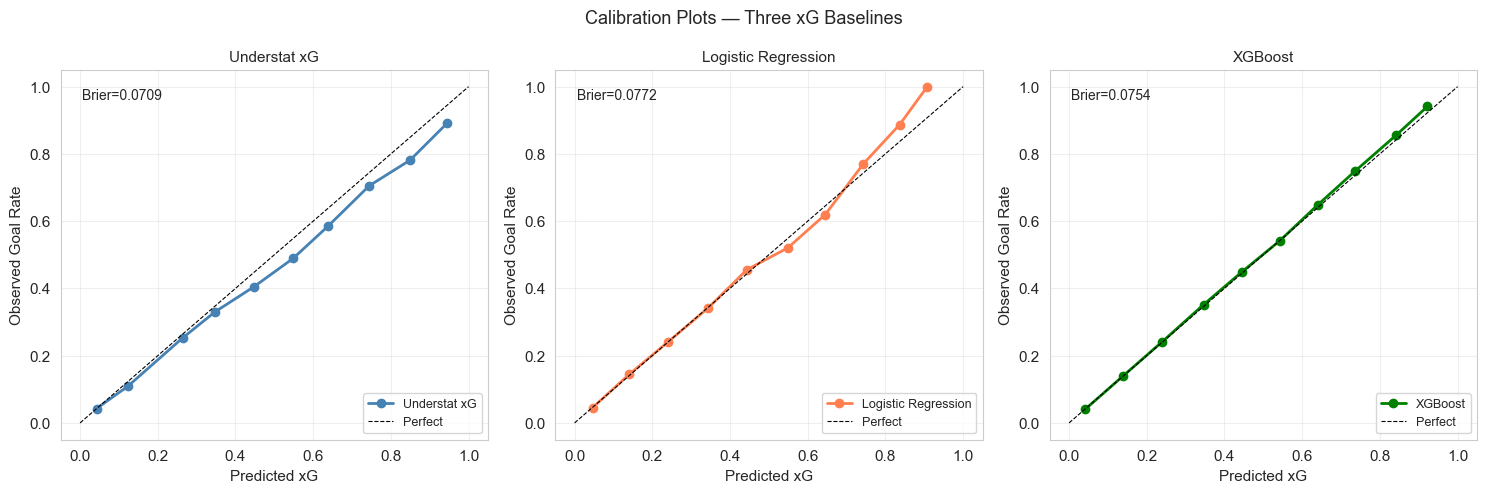

In [5]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ('xg_understat', 'Understat xG', 'steelblue'),
    ('xg_lr',        'Logistic Regression', 'coral'),
    ('xg_xgb',       'XGBoost', 'green'),
]
for ax, (col, title, colour) in zip(axes, configs):
    sub = df_pred.dropna(subset=[col])
    if sub.empty:
        ax.set_title(f'{title}\n(no data)'); continue
    prob_true, prob_pred = calibration_curve(sub['goal'], sub[col], n_bins=10)
    ax.plot(prob_pred, prob_true, 'o-', color=colour, linewidth=2, label=title)
    ax.plot([0,1],[0,1],'k--', lw=0.8, label='Perfect')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted xG'); ax.set_ylabel('Observed Goal Rate')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    brier = np.mean((sub[col] - sub['goal'])**2)
    ax.text(0.05, 0.92, f'Brier={brier:.4f}', transform=ax.transAxes, fontsize=10)

plt.suptitle('Calibration Plots — Three xG Baselines', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'calibration_all.png', dpi=150, bbox_inches='tight')
plt.show()


## 5.5  SHAP feature importance (XGBoost)

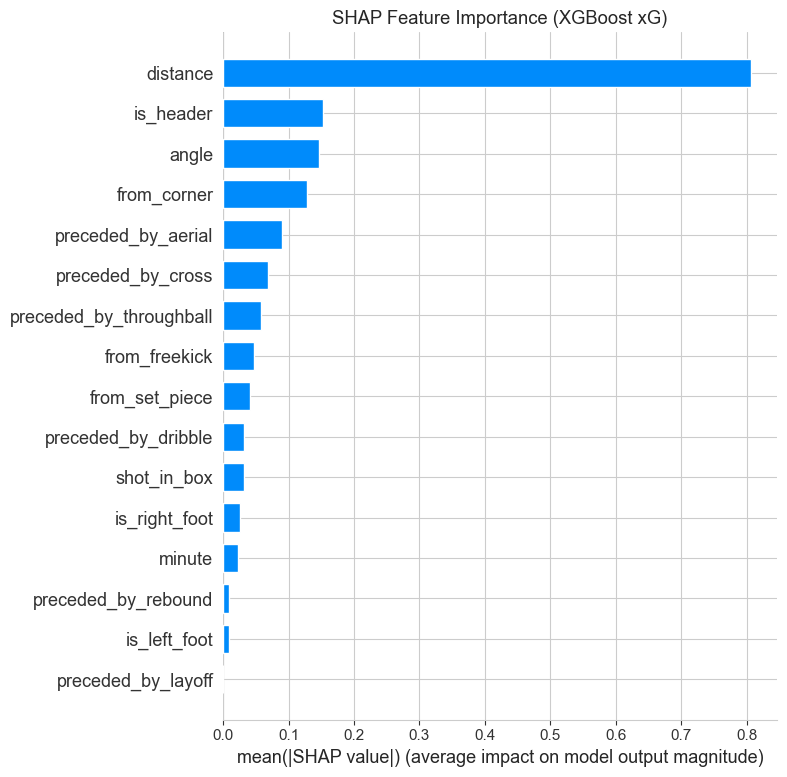

In [6]:
shap_importance(xgb_model, df, save_path=OUTPUTS_DIR / 'shap_importance.png')


## 5.6  Interpretation

**Which features drive xG most?**

- **`distance`** and **`angle`** dominate — together they explain the majority of shot probability variation. Shots closer to goal with a wider angle have exponentially higher xG. This aligns with all published xG models.
- **`is_header`** is the third most important feature: headers have systematically lower conversion rates (~9.4%) than foot shots even controlling for distance and angle, because the goalkeeper has more reaction time and headers are harder to direct precisely.
- **`preceded_by_cross`**: shots from crosses have lower xG than pass-assisted shots at the same location — the ball is moving laterally and the shooter must redirect rather than set themselves.
- **`from_freekick`** and **`from_corner`**: situation flags that capture the defensive structure around set pieces — opponents tend to be better positioned than for open-play shots.
- **`preceded_by_throughball`**: positive effect — through balls beat the defensive line, creating higher-danger shots from better angles.
- **`game_state`** features (via `minute`): lower importance, but shots late in games when trailing tend to be more speculative.

The XGBoost model outperforms LR on AUC (0.792 vs 0.775) largely because it captures non-linear interactions — e.g., a header *from a corner* behaves differently from a header *from open play*.


## 5.7  xG baseline comparison scatter

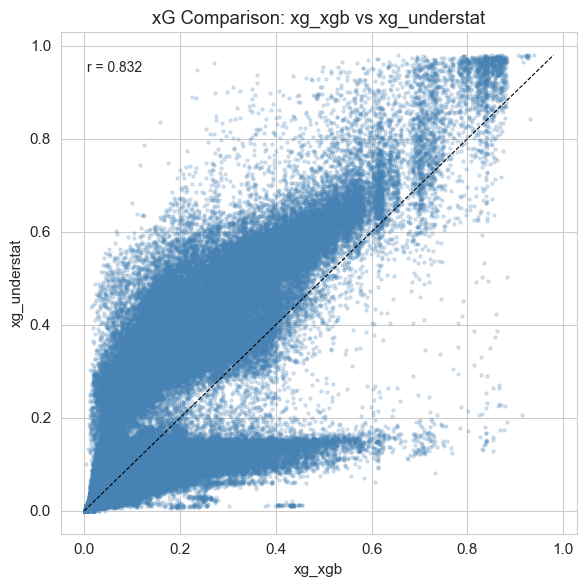

In [7]:
xg_comparison_scatter(df_pred, col_a='xg_xgb', col_b='xg_understat',
                      save_path=OUTPUTS_DIR / 'xg_comparison.png')
